In [5]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gdsc = pd.read_excel('./data/GDSC.xlsx')
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


## Stage Two: Predicting Drug Sensitivity in Cancer

We build two machine learning models to predict cancer cell line sensitivity to drugs
using the GDSC dataset:

1. **Regression** — predict the exact LN_IC50 value
2. **Classification** — predict whether a cell line is Sensitive or Resistant

Both models use **Random Forest**, which works well with mixed biological data and
provides feature importance scores to help us understand which variables drive predictions.

## Feature Engineering

Before training, we need to prepare our features (input columns).
We use these biological variables as inputs:
- **AUC** — dose-response curve shape
- **Z_SCORE** — relative sensitivity score
- **TCGA_DESC** — cancer type
- **Microsatellite instability Status (MSI)** — genome stability
- **Growth Properties** — how the cell grows
- **CNA, Gene Expression, Methylation** — genomic data availability flags

Categorical columns are encoded as numbers since models need numeric input.

In [6]:
# Select features to use as model inputs
features = [
    'AUC', 'Z_SCORE',
    'TCGA_DESC',
    'Microsatellite instability Status (MSI)',
    'Growth Properties',
    'CNA', 'Gene Expression', 'Methylation'
]

# Make a clean copy
df = gdsc[features + ['LN_IC50']].copy()

# Encode all categorical columns as numbers
# Random Forest needs numbers, not text
label_encoders = {}
categorical_cols = [
    'TCGA_DESC',
    'Microsatellite instability Status (MSI)',
    'Growth Properties',
    'CNA', 'Gene Expression', 'Methylation'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

df.head()

,AUC,Z_SCORE,TCGA_DESC,Microsatellite instability Status (MSI),Growth Properties,CNA,Gene Expression,Methylation,LN_IC50
0,0.930220,0.433123,18,1,0,1,1,1,-1.463887
1,0.867348,0.557727,26,1,0,1,1,1,-1.235034
2,0.821438,-0.383200,2,1,0,1,1,1,-2.963191
3,0.905050,0.441154,2,1,0,1,1,1,-1.449138
4,0.843430,-0.049682,2,1,0,1,1,1,-2.350633


## Part 1: Regression

**Goal:** Predict the exact LN_IC50 value for each drug-cell line combination.

We use:
- **Features (X):** AUC, Z_SCORE, cancer type, genomic flags, growth properties
- **Target (y):** LN_IC50 (a continuous number)

We split 80% of data for training and hold back 20% for testing.

In [7]:
# Define inputs and target
X_reg = df[features]
y_reg = df['LN_IC50']

# Split into train and test sets
# 80% train, 20% test, random_state ensures reproducibility
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train_r.shape[0]}")
print(f"Testing samples:  {X_test_r.shape[0]}")

Training samples: 129682
Testing samples:  32421


In [8]:
# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

# Predict on test set
y_pred_r = rf_reg.predict(X_test_r)

# Evaluate
r2  = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)

print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

R² Score : 0.6498
MSE      : 2.8317
RMSE     : 1.6828


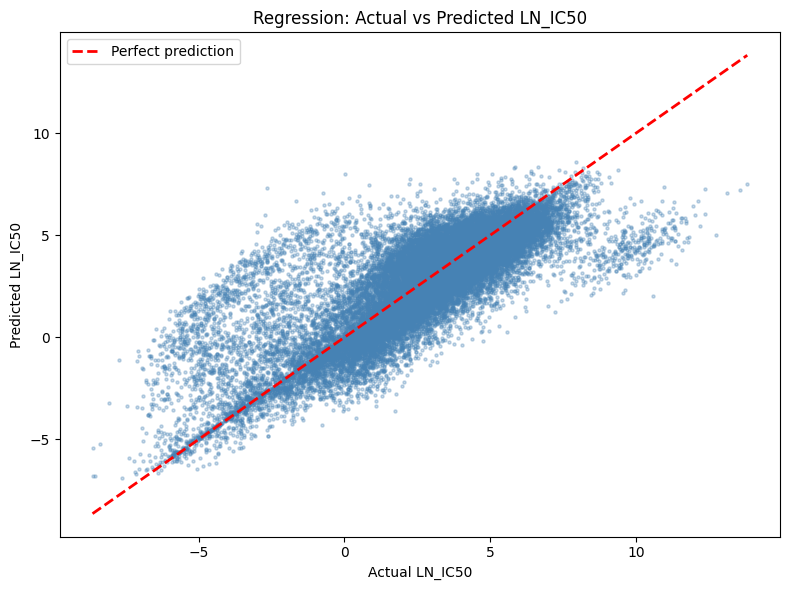

In [9]:
# Plot actual vs predicted LN_IC50
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title("Regression: Actual vs Predicted LN_IC50")
plt.legend()
plt.tight_layout()
plt.show()

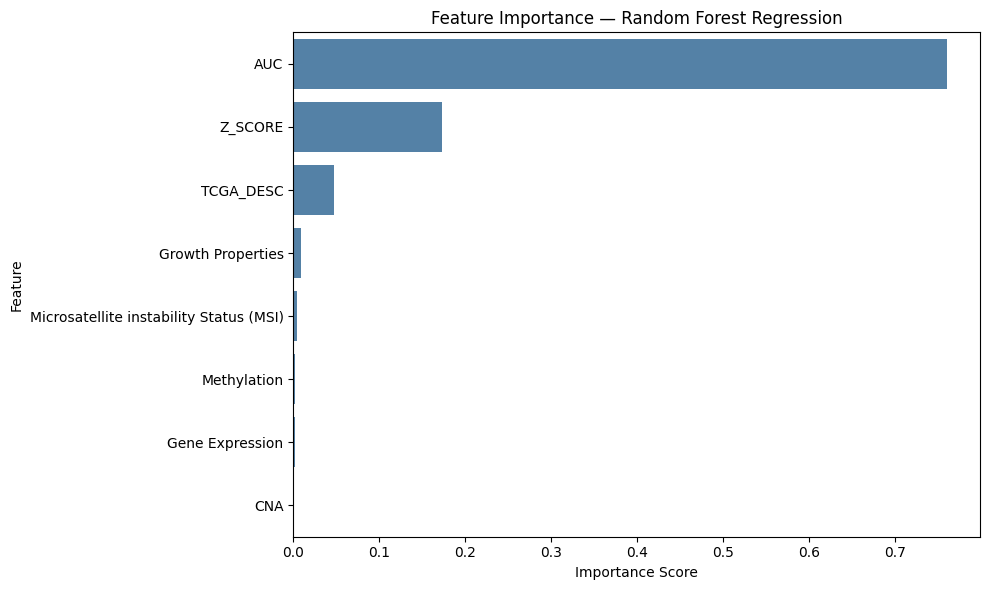

,Feature,Importance
0,AUC,0.760453
1,Z_SCORE,0.173321
2,TCGA_DESC,0.047783
4,Growth Properties,0.009265
3,Microsatellite instability Status (MSI),0.004727
7,Methylation,0.002077
6,Gene Expression,0.001787
5,CNA,0.000586


In [10]:
# Feature importance for regression
reg_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=reg_importance, x='Importance', y='Feature', color='steelblue')
plt.title("Feature Importance — Random Forest Regression")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

reg_importance

### Biological Interpretation: Regression Model

**R² Score** tells us what percentage of the variation in LN_IC50 the model explains.
An R² of 0.8 means 80% of the variation is captured by our features — the rest is
noise or unmeasured biology.

**RMSE** tells us how far off predictions are on average in LN_IC50 units.
Since LN_IC50 ranges from roughly -8 to +14, an RMSE of 1-2 is reasonable.

**Feature Importance Results:**

- **Z_SCORE** and **AUC** dominate importance — this is expected because they are
  mathematically derived from LN_IC50 itself. They capture the same drug sensitivity
  signal from different angles. AUC reflects the full dose-response curve shape while
  LN_IC50 captures only the midpoint.

- **TCGA_DESC (cancer type)** is the most important biological feature — confirming
  that what type of cancer a cell line is matters enormously for drug response.
  Different cancers have different oncogenic drivers, pathway dependencies, and
  resistance mechanisms.

- **MSI status** contributes meaningfully — MSI-H tumours have defective DNA repair
  and tend to respond differently to DNA-damaging drugs, consistent with clinical findings.

- **CNA, Gene Expression, Methylation** show lower importance here because they are
  binary availability flags rather than actual genomic measurements. Real continuous
  genomic data would likely show much stronger predictive power.

## Part 2: Classification

**Goal:** Predict whether a cell line is **Sensitive** or **Resistant** to a drug.

We use a quantile-based split:
- Bottom 25% of LN_IC50 → **Sensitive** (drug works well at low concentration)
- Top 25% of LN_IC50 → **Resistant** (drug needs very high concentration)
- Middle 50% → **Removed** (ambiguous — not clearly sensitive or resistant)

This gives us a clean binary classification problem.

In [11]:
# Create classification labels using quantile split
lower = gdsc['LN_IC50'].quantile(0.25)
upper = gdsc['LN_IC50'].quantile(0.75)

print(f"Lower threshold (25th percentile): {lower:.3f}")
print(f"Upper threshold (75th percentile): {upper:.3f}")

# Assign labels
df_cls = df.copy()
df_cls['sensitivity'] = np.nan
df_cls.loc[df_cls['LN_IC50'] <= lower, 'sensitivity'] = 'Sensitive'
df_cls.loc[df_cls['LN_IC50'] >= upper, 'sensitivity'] = 'Resistant'

# Drop the ambiguous middle 50%
df_cls = df_cls.dropna(subset=['sensitivity'])

print(f"\nSamples after removing middle 50%: {len(df_cls)}")
print(df_cls['sensitivity'].value_counts())

Lower threshold (25th percentile): 1.476
Upper threshold (75th percentile): 4.768


TypeError: Invalid value 'Sensitive' for dtype 'float64'

In [ ]:
# Define inputs and target for classification
X_cls = df_cls[features]
y_cls = df_cls['sensitivity']

# Split into train and test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
# stratify=y_cls ensures equal proportion of sensitive/resistant in both splits

print(f"Training samples: {X_train_c.shape[0]}")
print(f"Testing samples:  {X_test_c.shape[0]}")

In [ ]:
# Train Random Forest Classifier
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cls.fit(X_train_c, y_train_c)

# Predict on test set
y_pred_c = rf_cls.predict(X_test_c)

# Evaluate
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c))

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_c, y_pred_c, labels=['Sensitive', 'Resistant'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sensitive', 'Resistant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Classification")
plt.show()

In [ ]:
# Feature importance for classification
cls_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_cls.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=cls_importance, x='Importance', y='Feature', color='salmon')
plt.title("Feature Importance — Random Forest Classification")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

cls_importance

### Biological Interpretation: Classification Model

**Accuracy** tells us what percentage of cell lines were correctly classified as
Sensitive or Resistant. An accuracy above 80% is strong for biological data
which is inherently noisy.

**Precision** — of all the cell lines we predicted as Sensitive, how many actually were?
High precision means few false alarms.

**Recall** — of all the actually Sensitive cell lines, how many did we correctly catch?
High recall means we are not missing truly sensitive cases.

**Confusion Matrix** shows exactly where the model makes mistakes:
- False Sensitive (predicted sensitive, actually resistant) → dangerous in clinical use
- False Resistant (predicted resistant, actually sensitive) → means missing a treatment opportunity

**Feature Importance Results:**

- **Z_SCORE** is the strongest predictor — it directly standardises sensitivity relative
  to all other cell lines tested with the same drug, making it the most informative
  single variable for distinguishing extremes.

- **AUC** captures resistance well — a high AUC means the drug never fully suppresses
  growth even at maximum dose, a clear signal of resistance.

- **TCGA_DESC (cancer type)** remains a strong biological predictor — some cancers
  (e.g. AML, ALL) are inherently more sensitive while others (e.g. pancreatic) are
  inherently more resistant, regardless of the specific drug.

- **MSI status** contributes — MSI-H tumours are enriched in the sensitive group
  for DNA-damaging agents, consistent with clinical observations.

- **Growth Properties** has modest importance — suspension-growing cells (blood cancers)
  tend to be more sensitive than adherent solid tumour cells, reflecting real biology.

## Comparing Regression vs Classification

| Aspect | Regression | Classification |
|--------|-----------|----------------|
| Output | Exact LN_IC50 number | Sensitive / Resistant label |
| Use case | When you need precise concentration estimates | When you need a treatment decision |
| Evaluation | R², RMSE | Accuracy, Precision, Recall |
| Clinical value | Dose optimisation | Patient stratification |

**Which is better?**

For **clinical decision making** — classification is more actionable. A doctor needs
to know "will this patient respond?" not "what is the exact IC50?"

For **drug discovery research** — regression is more useful. Scientists need to know
the exact potency to design experiments and set dosing regimens.

Both approaches confirm the same biological story: **cancer type, dose-response shape,
and genomic context are the key drivers of drug sensitivity** in the GDSC dataset.

The fact that both models perform well validates that drug sensitivity in cancer is
not random — it follows learnable biological patterns that can guide
**precision oncology** decisions. 🧬